
# How much can we trust a model response? Does a model handle the aerosol-forced monsoon response realistically?

The goal is to estimate model uncertainity and check if SAI creates any signal (change>uncertainty), for \
    spatial rainfall anomalies or changes \
    ITCZ deviations or shifts 
- 20260218_JJAS_NDJF_PR_BIAS.ipynb : piControl versus Historical
- 20260220_JJAS_NDJF_PR_BIAS_SSP585.ipynb : Historical versus SSP585
- 20260221_JJAS_NDJF_PR_BIAS_SSP245.ipynb : Historical versus SSP245
- 20260221_JJAS_NDJF_PR_BIAS_G6Sulfur.ipynb : Historical versus G6sulfur

In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

Compute 

    JJAS and NDJF mean of OBS (TRMM)
    JJAS and NDJF for models : 
                                piControl, historical, SS585 bias (over historial) : bias

OBS - piControl: Tells you the model's baseline bias — how well the model simulates monsoon rainfall in the absence of any external forcing. This is the "pure" model structural error.

OBS - Historical: Tells you the model's bias in the forced climate — combining structural model error + how well the model responds to actual historical forcings.

Comparing the two: If (OBS - Historical) ≠ (OBS - piControl), it means the forcing response itself is biased — the model doesn't accurately simulate how monsoon rainfall changed due to anthropogenic/natural forcing, beyond its baseline structural errors.

In short: piControl bias = model's inherent error; Historical bias = model's inherent error + forcing response error. Their difference isolates the model's error in simulating forced monsoon changes.

piControl→Historical: Does anthropogenic forcing distort model skill? \
Historical→SSP585: Does intensified warming amplify/shift biases? \
Historical→SAI: Does cooling-based geoengineering create distinct bias patterns — i.e., does the model handle the aerosol-forced monsoon suppression realistically?


**Since all data needs to be in one grid resolution, I am regridding to 2.5x2.5 degrees**

I have 6 models:
1. Check consistency across models:
If all 6 models show similar (OBS-Historical) ≠ (OBS-piControl), it suggests a robust, systematic problem in how models respond to forcing — not a model-specific artifact.
2. Quantify the "forcing-induced bias change":
For each model, compute: **Δbias = (OBS-Historical) − (OBS-piControl)**
This isolates each model's error in simulating the forced response. Then compare Δbias across 6 models — do they agree in sign and magnitude?
3. Model ranking/weighting:
**Models where Δbias is small are better at simulating the forced monsoon response, and could be given higher weight in an ensemble for future projections.**
4. Identify inter-model spread:
If Δbias varies widely across the 6 models, it highlights uncertainty in how forcing affects monsoon — some models may overestimate, others underestimate the forced signal.
5. Bias stationarity assessment:
If a model's bias is stationary (OBS-Historical ≈ OBS-piControl), bias correction trained on historical period is more reliable for that model. Models with large Δbias violate stationarity — their bias corrections are less trustworthy for future scenarios.
This framework helps you select, weight, or flag models before using them for SAI or SSP585 projections.

I have historical from 1850-2014 and picontrol from 1850-2849 : I am planing to use 30year climatology of HIST and 30year climatology of picontrol and 30 year climatology of OBS. Now if there is a certain amount of uncertainty (standard deviation between mean of different 30 years of HIST and same for picontrol), how do I use that uncertainty information to assess Δbias?

**Setting up the uncertainty:**

- From Historical (1850–2014): You have limited non-overlapping 30-year windows (e.g., ~5 windows). Compute mean climatology for each → get spread (SD) across these means = **uncertainty in HIST climatology (σ_hist)**
- From piControl (1850–2849): You have many non-overlapping 30-year windows (~33 windows). Compute mean climatology for each → SD across these = **uncertainty in piControl climatology (σ_pi)**
- OBS is fixed (one 30-year climatology), so it has no sampling uncertainty in this framework.

**Assessing Δbias with uncertainty:**

Δbias = (OBS − HIST) − (OBS − piControl) = **piControl_mean − HIST_mean**

Uncertainty in Δbias:
**σ_Δbias = √(σ_hist² + σ_pi²)**

**Key assessment:**

- If **|Δbias| > σ_Δbias** (or use 2σ for 95% confidence): the forcing-induced bias change is **statistically significant** — the model genuinely responds differently to forcing.
- If **|Δbias| ≤ σ_Δbias**: the difference could simply be due to **internal variability**, not forcing — Δbias is not distinguishable from noise.

**Across 6 models:**
Check how many models show significant Δbias — if most do, the forced bias change is robust across the ensemble, strengthening your conclusion that:

**The model's bias is not stationary — it genuinely changes due to external forcing, beyond what internal variability alone can explain.**

Specifically, if most of the 6 models show significant Δbias, you can robustly conclude that:

- Historical forcing (anthropogenic + natural) systematically shifts model bias in simulating monsoon rainfall
- This shift is not just random internal variability — it reflects the model's **structural inability to correctly respond to forcing**
- Therefore, bias correction assuming stationarity (i.e., same bias in past and future) is **unreliable** for these models
- And by extension, projections under SSP585 or SAI from these models carry an additional layer of uncertainty beyond just spread across models

If you use multiple observational datasets (e.g., GPCP, TRMM, ERA5) for the same 30-year period, you get observational uncertainty (σ_obs) from the spread across them.
Then Δbias uncertainty becomes:
**σ_Δbias = √(σ_hist² + σ_pi² + 2·σ_obs²)**
(σ_obs appears twice because OBS enters both (OBS−HIST) and (OBS−piControl))

In [2]:
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means

In [3]:
import xarray as xr
from pathlib import Path

In [4]:
import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

In [5]:
# =========================
# User-defined metadata
# =========================

varname = "pr"
varname_T = "tas"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

In [6]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [7]:
#Experiment details
EXPERIMENTS = {
    # "piControl":     {"project": "CMIP",        "scenario": "piControl",  "color": "black"},
    # "HIST":          {"project": "CMIP",        "scenario": "historical", "color": "black"},
    "SSP245":        {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":        {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":       {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":      {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

In [8]:
import numpy as np

def global_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    return da.weighted(weights).mean(('lat', 'lon'))

In [9]:

all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_T={}
    var_T_mean={}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():
        # if exp not in ["SSP245", "G6sulfur", "G6solar", "piControl"]:
        #     continue

        # open dataset
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]


        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        base_T = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname_T
            / model_meta["grid"]
            / "latest"
        )

        ######## ds for PR ############
        print(str(base))
        # ds = mf.open_files(str(base))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        ###############################

        ######## ds for T ############
        print(str(base_T))
        # ds = mf.open_files(str(base))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_T = mf.open_files_CESM_G6sulfur(base_T)
            elif meta["scenario"] == "ssp585":
                ds_T = mf.open_files_CESM_ssp585(base_T)
            else:
                ds_T = mf.open_files(str(base_T))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_T = mf.open_files_IPSL_ssp585(base_T)
            else:
                ds_T = mf.open_files(str(base_T))
        else:
            ds_T = mf.open_files(str(base_T))
        ###############################

        
        # ds = ...
        var[exp] = mf.read_var(ds, varname)
        
        # if exp not in ["SSP585"]:
        #     continue
        var_T[exp] = mf.read_var(ds_T, varname_T)

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR
    # ----------------------------
    for exp, da in var.items():
        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da, 11, 2),
            "ANN":  mf.seasonal_mean_by_year_old(da, 1, 12)
        }
        
    for exp, da in var_T.items():    
        # if exp not in ["SSP585"]:
        #     continue
        var_T_mean[exp] = {
            "ANN": mf.climatological_mean(da, 1, 12)
        }
    
    
    # ----------------------------
    # 3) 30-YR CLIMATOLOGY
    # ----------------------------
    results = {}
    
    for exp in var_by_year:
    
        results[exp] = {}
    
        for season in ["SUM", "WIN", "ANN"]:
    
            da_year = var_by_year[exp][season]
    
            clim_mean, clim_sd, block_means = climatology_and_uncertainty(da_year)
    
            results[exp][season] = {
                "mean": clim_mean,
                "sd": clim_sd,
                "blocks": block_means
            }

    # ----------------------------
    # 4) Δbias (AFTER results built)
    # ----------------------------
    if "G6sulfur" in results and "SSP245" in results:

        mean_exp1 = {}
        mean_exp2 = {}

        delta_T = float(
            global_mean(var_T_mean["G6sulfur"]["ANN"]).compute() - 
            global_mean(var_T_mean["SSP245"]["ANN"]).compute()
        )
        print(f"ΔT (G6sulfur - SSP245) = {delta_T:.3f} K")

        
        for season in ["SUM", "WIN", "ANN"]:

            mean_G6sulfur = results["G6sulfur"][season]["mean"] 
            mean_SSP245 = results["SSP245"][season]["mean"]
    
            mean_exp1[season] = mean_G6sulfur
            mean_exp2[season]   = mean_SSP245
    
        results["mean_G6sulfur"] = mean_exp1
        results["mean_SSP245"]   = mean_exp2
        
    # Save results for models:
    all_results[model_name] = results

/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/tas/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/tas/gn/latest
ΔT (G6sulfur - SSP245) = 0.157 K
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/tas/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/tas/gr/latest
ΔT (G6sulfur - SSP245) = 0.158 K
/badc/cmip6/data/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp245/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp245/r1i1p1f1/Amon/tas/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/minif

ΔT (G6sulfur - SSP245) = 0.014 K
/badc/cmip6/data/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp245/r1i1p1f1/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp245/r1i1p1f1/Amon/tas/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/Amon/tas/gr/latest
ΔT (G6sulfur - SSP245) = 0.091 K


In [16]:
def compute_monsoon_mask(mean_summer, mean_winter, mean_annual,
                          precip_threshold=2.0, summer_fraction=0.55):
    """
    Global monsoon domain using seasonal TOTALS:
    - (summer_total - winter_total) / 4 > precip_threshold (mm/day difference)
    - summer_total / annual_total > summer_fraction
    """
    # Convert to mm/day
    s   = mean_summer ;#* 86400
    w   = mean_winter ;#* 86400
    ann = mean_annual ;#* 86400

    # Seasonal totals (proportional to mm)
    s_total   = s   * 4
    w_total   = w   * 4
    ann_total = ann * 12

    cond1 = (s_total - w_total) / 4 > precip_threshold        # difference in mm/day
    cond2 = (s_total / ann_total.where(ann_total > 0)) > summer_fraction  # fraction

    return (cond1 & cond2).astype(float)


# Compute monsoon masks for all models
monsoon_masks = {}

for model_name, results in all_results.items():
    if "SSP245" in results and "G6sulfur" in results:
        monsoon_masks[model_name] = {}

        for exp in ['SSP245', 'G6sulfur']:
            mean_summer = results[exp]['SUM']['mean'].compute()
            mean_winter = results[exp]['WIN']['mean'].compute()
            mean_annual = results[exp]['ANN']['mean'].compute()

            monsoon_masks[model_name][exp] = compute_monsoon_mask(
                mean_summer, mean_winter, mean_annual
            )
            print(f"{model_name} {exp}: monsoon mask computed")

UKESM1-0-LL SSP245: monsoon mask computed
UKESM1-0-LL G6sulfur: monsoon mask computed
CNRM-ESM2-1 SSP245: monsoon mask computed
CNRM-ESM2-1 G6sulfur: monsoon mask computed
MPI-ESM1-2-LR SSP245: monsoon mask computed
MPI-ESM1-2-LR G6sulfur: monsoon mask computed
CESM2-WACCM SSP245: monsoon mask computed
CESM2-WACCM G6sulfur: monsoon mask computed
IPSL-CM6A-LR SSP245: monsoon mask computed
IPSL-CM6A-LR G6sulfur: monsoon mask computed


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np

def plot_monsoon_contours(monsoon_masks, trop_bound=30):

    model_names = list(monsoon_masks.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4),
                              subplot_kw={'projection': ccrs.PlateCarree()})

    if n_models == 1:
        axes = [axes]

    colors = {'SSP245': 'blue', 'G6sulfur': 'red'}
    labels = {'SSP245': 'SSP245', 'G6sulfur': 'G6sulfur'}

    for ax, model_name in zip(axes, model_names):
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

        for exp in ['SSP245', 'G6sulfur']:
            if exp not in monsoon_masks[model_name]:
                continue

            mask = monsoon_masks[model_name][exp]
            lat  = mask.lat
            lon  = mask.lon

            ax.contour(lon, lat, mask,
                       levels=[0.5],
                       colors=colors[exp],
                       linewidths=1.2,
                       transform=ccrs.PlateCarree())

        ax.set_extent([-180, 180, -trop_bound, trop_bound],
                      crs=ccrs.PlateCarree())
        ax.set_aspect('auto')

        ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(-trop_bound, trop_bound+1, 15), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=7)
        ax.set_title(model_name, fontsize=9)

    # Shared legend
    legend_handles = [
        mpatches.Patch(color=colors[exp], label=labels[exp])
        for exp in ['SSP245', 'G6sulfur']
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle('Global Monsoon Domain\n(summer−winter > 2 mm/day & summer > 55% annual)',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    # plt.savefig('monsoon_contours_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()



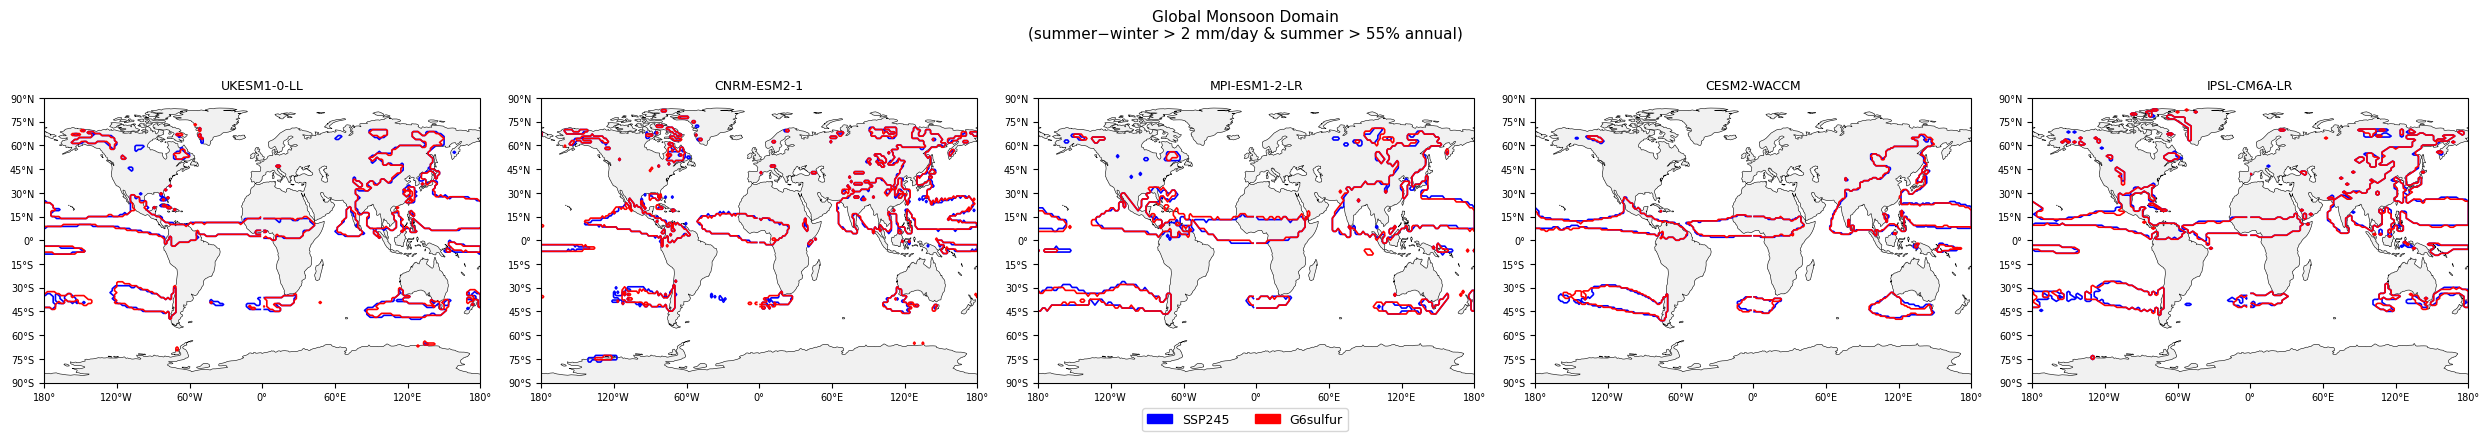

In [13]:
# Plot
plot_monsoon_contours(monsoon_masks, trop_bound=90)

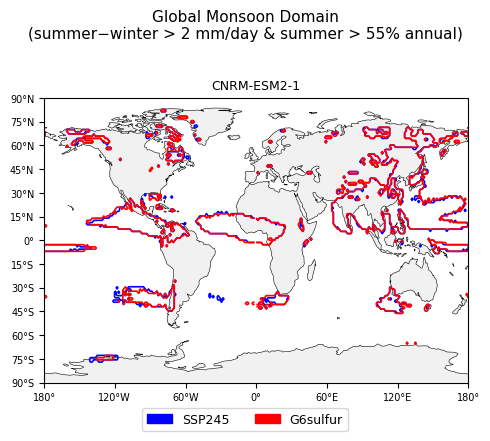

In [15]:
# First model only
first_model = list(monsoon_masks.keys())[1]
plot_monsoon_contours({first_model: monsoon_masks[first_model]}, trop_bound=90)